In [5]:
import sys
import os
sys.path.append(os.path.abspath("../../src"))

import scanpy as sc
from dmt import DyMoTree

adata = sc.read_h5ad("../../data/bench/simulate/anndata/anndata.h5ad")
dmt = DyMoTree(adata=adata,
               k=50,
               progenitor='Stem',
               terminal=['Child1','Child2'],
               lineage_col='celltype',
               emb_key='emb', 
               device='cuda',
               seed=1024)

dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')

Successfully loaded state: Stem, cells: 2461
Successfully loaded state: Child1, cells: 1285
Successfully loaded state: Child2, cells: 1254
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'Stem' (Edges: 120589)
[*] Intra-state graph built for 'Child1' (Edges: 62965)
[*] Intra-state graph built for 'Child2' (Edges: 61446)
[*] Calculating composite similarity between progenitor 'Stem' and terminals ['Child1', 'Child2']...
[*] Inter-state graph built for 'Child1' (Edges: 1012282)
[*] Inter-state graph built for 'Child2' (Edges: 1076914)


In [6]:
dmt.train(pre_train = 'combined',
              lr = {'formal':1e-4,
                    'intra':1e-3,
                    'lineage':1e-4},
              iter = {'formal':300,
                    'intra':100,
                    'lineage':300},
              sample_ratio = 256,
              alpha = 0)

:: Stage1 Pre-training -- intra-state transition graph::
:: Do pre-train Graph encoder for Stem ::


100%|██████████████████████████████████████████████████| 100/100 [00:11<00:00,  9.09it/s, loss=1.13]


:: Do pre-train Graph encoder for Child1 ::


100%|██████████████████████████████████████████████████| 100/100 [00:05<00:00, 17.47it/s, loss=1.72]


:: Do pre-train Graph encoder for Child2 ::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 300/300 : 100%|█████████████████████████████████| 300/300 [01:04<00:00,  4.65it/s, loss=0.786]


:: DyMoTree Training::


Iter: 300/300 : 100%|██████████████████████████████████| 300/300 [01:04<00:00,  4.65it/s, loss=1.08]

[2026-04-16 15:30:17] get fate space of Stem


<Axes: title={'center': 'fate_bias'}, xlabel='plt1', ylabel='plt2'>

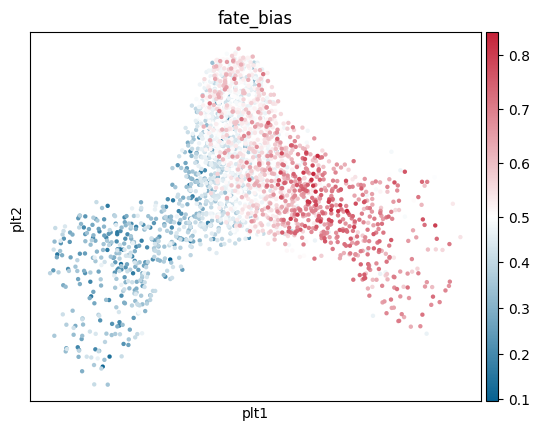

In [10]:
import matplotlib.colors as mcolors
import pandas as pd
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)

progenitor = dmt.treedata.get_node('Stem',adata_object=True)
progenitor.obs['fate_bias'] = dmt.cal_fate_bias(progenitor.obs['Child1_fate'], progenitor.obs['Child2_fate'])
sc.pl.embedding(progenitor, basis='plt', color=['fate_bias'], show=False,cmap=custom_bwr,vcenter=0.5,size=40)

In [21]:
# find cell state
dmt.find_state(n_state=3,
               n_pca=10,
               n_diff=10,
               n_gene=10,
               method='spearman')

[2026-04-16 15:35:30] find cell state of Stem
[2026-04-16 15:35:30] Filtering Data by fate space
[2026-04-16 15:35:33] PCA transformation
[2026-04-16 15:35:34] Run Diffusion map
[2026-04-16 15:35:37] Find archetypes


<Axes: title={'center': 'Fate_State'}, xlabel='plt1', ylabel='plt2'>

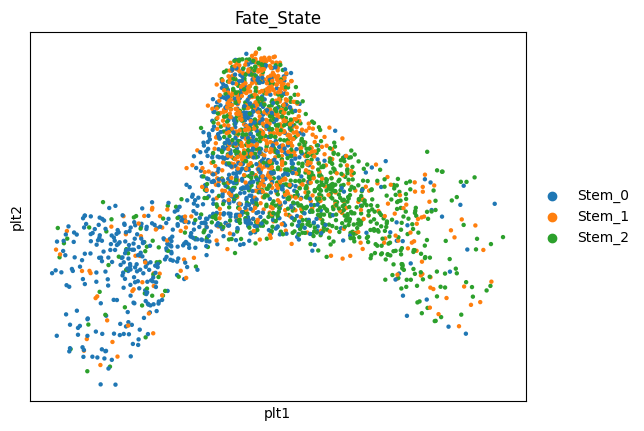

In [22]:
hspc = dmt.treedata.get_node('Stem',adata_object=True)
sc.pl.embedding(hspc, basis='plt', color=['Fate_State'], show=False,cmap='bwr',vcenter=0.5,size=40)